# Violent Crime Capstone

This notebook runs Linear Regression and Random Forest using:
- Target: Murder Rate
- Unemployment %
- Poverty %
- Bachelor's or Higher %
- Income (K)
- Population Density
- Income Per Density
- State

## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

BASE_DIR = Path.cwd()
CLEAN_DATA = BASE_DIR / 'cleaned_data'
OUTPUTS = BASE_DIR / 'outputs'

CLEAN_DATA.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)


## 2. Load Dataset, Income Rescaling, and Calculating Income Per Density

In [2]:
import pandas as pd

df = pd.read_csv("capstone_count_rate_density.csv")
df.head()


,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,larceny_theft,motor_vehicle_theft,arson,year,state.1,county_clean,fips,county.1,labor_force,employed,unemployed,unemployment_pct,median_income,poverty_pct,bachelors_or_higher_pct,population,violent_crime_rate_per_100k,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate,county_state,poverty_bin,unemployment_bin,education_bin,GEOID,ALAND,land_area_sq_miles,population_density
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,143,32,1,2024,AL,AUTAUGA,1001,"Autauga County, AL","28,467.000","27,702.000",765.000,2.700,"72,481.000",11.300,29.100,59947,90.080,1.668,11.677,0.000,76.734,"Autauga, ALABAMA",Medium-Low,Low,Medium-High,1001,1539631459,594.455,100.844
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,142,5,2,2024,AL,BALDWIN,1003,"Baldwin County, AL","116,653.000","113,448.000","3,205.000",2.700,"78,775.000",10.100,33.700,246989,55.468,0.000,1.620,0.000,53.849,"Baldwin, ALABAMA",Low,Low,High,1003,4117781416,"1,589.884",155.350
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,43,9,0,2024,AL,BIBB,1007,"Bibb County, AL","8,710.000","8,446.000",264.000,3.000,"52,541.000",22.500,11.700,22130,153.638,0.000,22.594,0.000,131.044,"Bibb, ALABAMA",High,Low,Low,1007,1612188713,622.470,35.552
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,180,52,2,2024,AL,BLOUNT,1009,"Blount County, AL","26,922.000","26,204.000",718.000,2.700,"64,190.000",12.900,15.800,59518,137.773,1.680,30.243,3.360,102.490,"Blount, ALABAMA",Medium-Low,Low,Low,1009,1670259099,644.891,92.292
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,144,0,8,2024,AL,CALHOUN,1015,"Calhoun County, AL","49,605.000","47,995.000","1,610.000",3.200,"55,029.000",17.900,20.600,116090,205.013,1.723,4.307,0.000,198.984,"Calhoun, ALABAMA",High,Low,Medium-Low,1015,1569256885,605.893,191.601


In [3]:
df['income_k'] = df['median_income'] / 1000

In [4]:
df['income_per_density'] = df['income_k'] / df['population_density']

In [5]:
df.dtypes

state                                             str
metropolitan_nonmetropolitan                      str
county                                            str
violent_crime_count                             int64
murder_and_nonnegligent_manslaughter_count      int64
rape_count                                      int64
robbery_count                                   int64
aggravated_assault_count                        int64
property_crime                                  int64
burglary                                        int64
larceny_theft                                   int64
motor_vehicle_theft                             int64
arson                                           int64
year                                            int64
state.1                                           str
county_clean                                      str
fips                                            int64
county.1                                          str
labor_force                 

In [6]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State",
    "county_state": "County State",
    "land_area_sq_miles": "Land Area (Square Miles)",
    "population_density": "Population Density",
    "income_k": "Income (Rescaled)",
    "income_per_density": "Income Per Density"
}


In [7]:
def clean_label(x):
    # Handle state dummies
    if x.startswith('state_'):
        return x.replace('state_', '').title()
    
    # Handle known feature names
    return label_map.get(x, x)

## 3. Modeling Preperation: Linear Regression and Random Forest

We use two regression models to predict county-level violent crime counts from socioeconomic factors.  
Linear regression serves as a baseline, interpretable model that shows the direction and size of relationships between predictors and violent crime.  
Random forest regression is used as a more flexible model that can capture nonlinear relationships and interactions between predictors.  
Comparing both models allows us to balance interpretability and predictive performance while also identifying which socioeconomic variables are the strongest predictors of violent crime.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [9]:
# log-transform target
# compresses large values and reduces skew
df['log_violent_crime_rate_per_100k'] = np.log1p(df['violent_crime_rate_per_100k'])
df['log_murder_and_nonnegligent_manslaughter_rate'] = np.log1p(df['murder_and_nonnegligent_manslaughter_rate'])
df['log_rape_rate'] = np.log1p(df['rape_rate'])
df['log_robbery_rate'] = np.log1p(df['robbery_rate'])
df['log_aggravated_assault_rate'] = np.log1p(df['aggravated_assault_rate'])

# make dummy variables
df_model = df.copy()

df_model = pd.get_dummies(
    df_model,
    columns=['state', 'metropolitan_nonmetropolitan'],
    drop_first=True,
    dtype=int
)

# only keep numeric dummy columns, not raw text columns like state_abbr
dummy_features = [c for c in df_model.columns if 'state_' in c]

base_features = [
    'unemployment_pct',
    'poverty_pct',
    'bachelors_or_higher_pct',
    'income_k',
    'population_density',
    'income_per_density',
]

features = base_features + dummy_features


In [10]:
df_model[base_features + dummy_features].info()

<class 'pandas.DataFrame'>
RangeIndex: 1858 entries, 0 to 1857
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unemployment_pct         1858 non-null   float64
 1   poverty_pct              1858 non-null   float64
 2   bachelors_or_higher_pct  1858 non-null   float64
 3   income_k                 1858 non-null   float64
 4   population_density       1858 non-null   float64
 5   income_per_density       1858 non-null   float64
 6   state_ARIZONA            1858 non-null   int64  
 7   state_ARKANSAS           1858 non-null   int64  
 8   state_CALIFORNIA         1858 non-null   int64  
 9   state_COLORADO           1858 non-null   int64  
 10  state_FLORIDA            1858 non-null   int64  
 11  state_GEORGIA            1858 non-null   int64  
 12  state_IDAHO              1858 non-null   int64  
 13  state_ILLINOIS           1858 non-null   int64  
 14  state_INDIANA            1858 non-n

## 4. Modeling All Murder Rate

In [11]:
target = 'log_murder_and_nonnegligent_manslaughter_rate'

df_model = df_model.dropna(subset=features + [target]).copy()

X = df_model[features]
y = df_model[target]

print("Any object columns in X?")
print(X.select_dtypes(include='object').columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of features:", len(features))

Any object columns in X?
[]
Training shape: (1486, 49)
Testing shape: (372, 49)
Number of features: 49


Linear Regression (All Violent Crime)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("R^2:", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 4))
print("MAE:", round(lr_mae, 4))

Linear Regression Results
R^2: 0.1255
RMSE: 0.7289
MAE: 0.5624


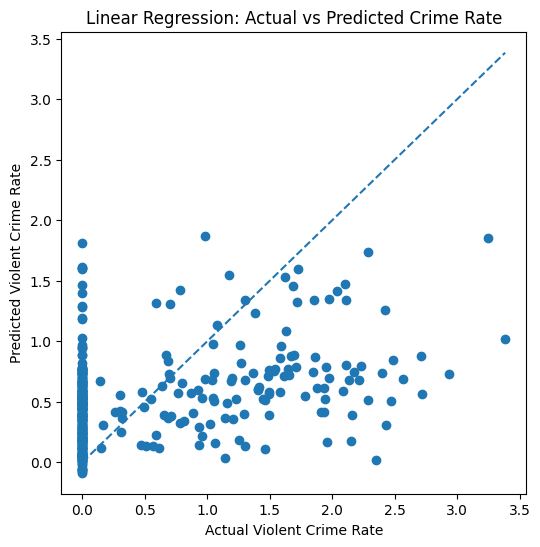

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Linear Regression: Actual vs Predicted Crime Rate")
plt.show()

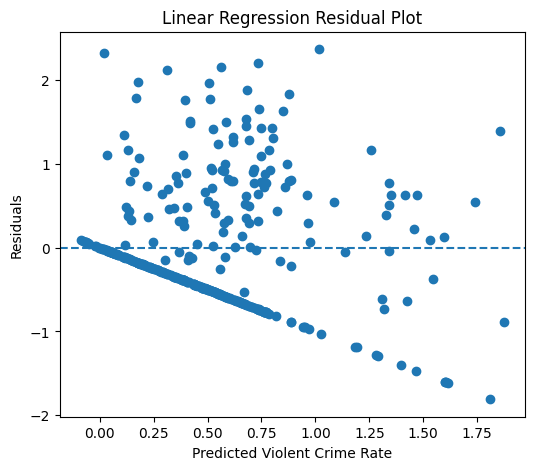

In [14]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_lr, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Violent Crime Rate")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

In [15]:
coef_lf = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_lf

,Feature,Coefficient
38,state_SOUTH CAROLINA,0.827
29,state_NEW JERSEY,-0.779
17,state_KENTUCKY,-0.739
37,state_PENNSYLVANIA,-0.677
32,state_NORTH CAROLINA,0.671
19,state_MAINE,-0.642
22,state_MINNESOTA,-0.595
13,state_ILLINOIS,-0.589
28,state_NEW HAMPSHIRE,-0.559
43,state_VERMONT,-0.553


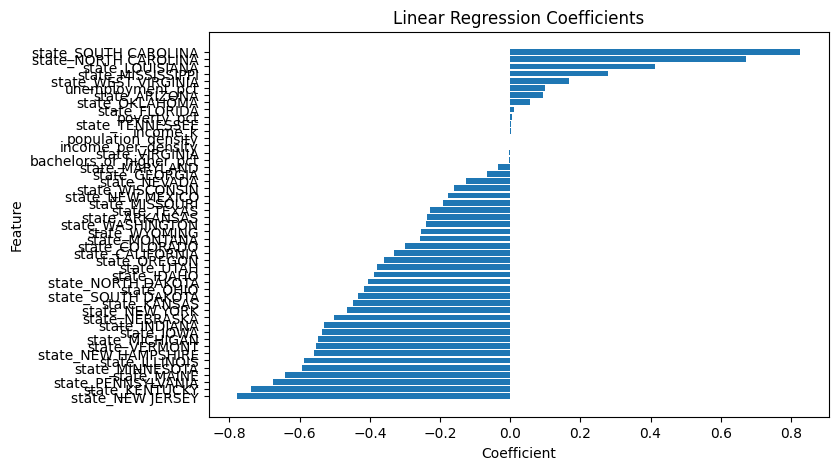

In [16]:
top_lr = coef_lf.sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.barh(top_lr['Feature'], top_lr['Coefficient'])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.show()

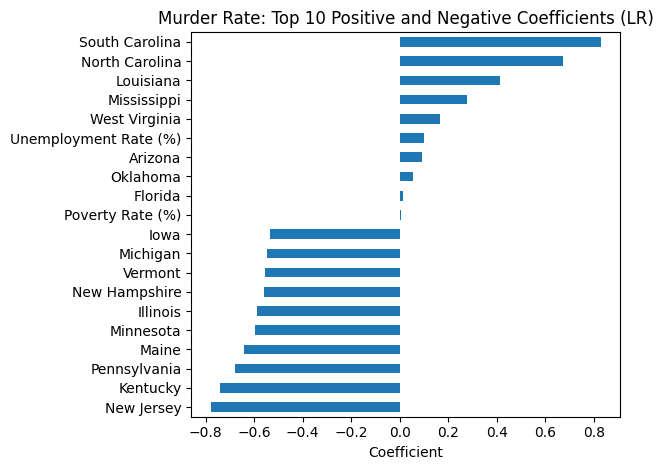

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

coefs = pd.Series(lr.coef_, index=X.columns)
top_n = 10
top_pos = coefs.sort_values(ascending=False).head(top_n)
top_neg = coefs.sort_values().head(top_n)

top_combined = pd.concat([top_neg, top_pos])

# Labels
top_combined.index = [clean_label(x) for x in top_combined.index]

# Plot
top_combined.sort_values().plot(kind='barh')

plt.title("Murder Rate: Top 10 Positive and Negative Coefficients (LR)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Random Forest (All Violent Crime)

In [18]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results")
print("R^2:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

Random Forest Results
R^2: 0.0716
RMSE: 0.7511
MAE: 0.5639


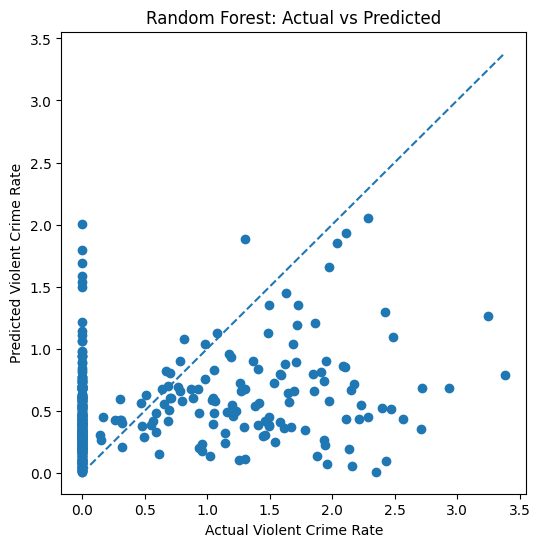

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [20]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance

,Feature,Importance
3,income_k,0.156
1,poverty_pct,0.125
2,bachelors_or_higher_pct,0.121
4,population_density,0.120
0,unemployment_pct,0.112
5,income_per_density,0.106
32,state_NORTH CAROLINA,0.052
38,state_SOUTH CAROLINA,0.039
18,state_LOUISIANA,0.025
17,state_KENTUCKY,0.013


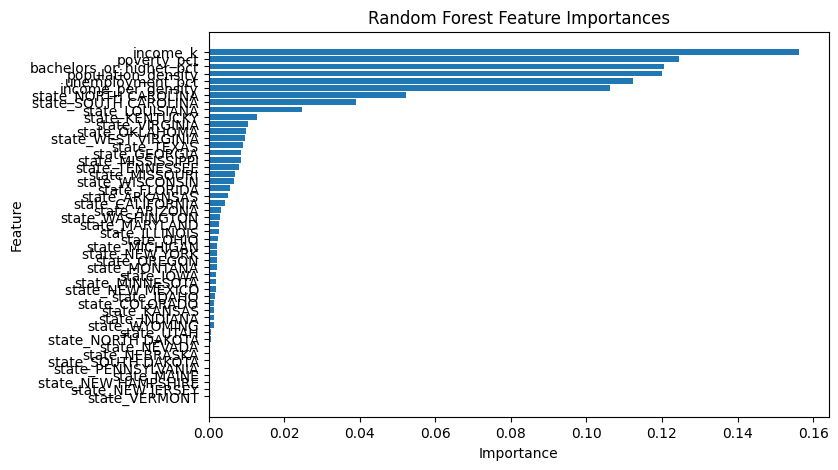

In [21]:
top_rf = rf_importance.sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.show()

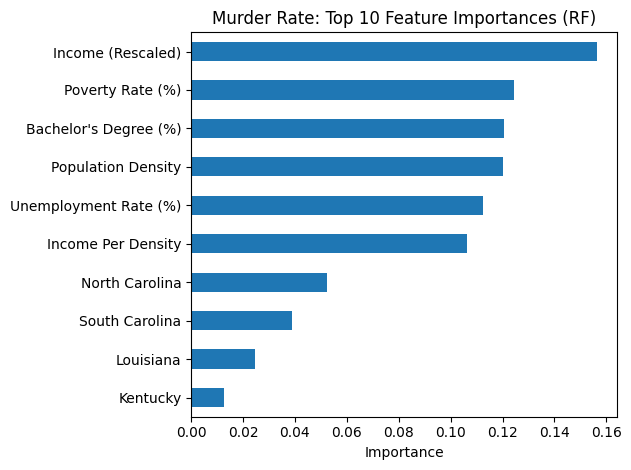

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_n = 10
top_features = importances.sort_values(ascending=False).head(top_n)

# Labels
top_features.index = [clean_label(x) for x in top_features.index]

top_features.sort_values().plot(kind='barh')
plt.title("Murder Rate: Top 10 Feature Importances (RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Comparison Linear Regression vs. Random Forest (All Crime)

In [23]:
results_df = pd.DataFrame({
    'Murder Rate Model': ['Linear Regression', 'Random Forest'],
    'R^2': [lr_r2, rf_r2],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae]
})

results_df

,Murder Rate Model,R^2,RMSE,MAE
0,Linear Regression,0.126,0.729,0.562
1,Random Forest,0.072,0.751,0.564
